In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DATASET OVERVIEW

In [2]:
df = pd.read_csv("House_Prediction_dataset.csv")

In [3]:
# shape
df.shape

(1460, 81)

In [4]:
# previewing the data
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# coloumns
df.columns.values

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

In [6]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
# describe
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# MISSING VALUE ANALYSIS

In [8]:
# gettting the null vlaues
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [9]:
# filling the null values
# strategy -> mean
df['LotFrontage'].fillna( df['LotFrontage'].mean() , inplace = True)

/tmp/ipykernel_27194/2502723170.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna( df['LotFrontage'].mean() , inplace = True)


In [10]:
# gettting the null vlaues
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [51]:
print( df.isnull().sum()[df.isnull().sum() > 0] )
print( np.dtype(df["MasVnrArea"]) )
print( np.dtype(df["GarageYrBlt"]) )

MasVnrArea      8
GarageYrBlt    81
dtype: int64
float64
float64


In [52]:
df["MasVnrArea"].fillna(df["MasVnrArea"].median() , inplace = True)

/tmp/ipykernel_27194/1554734384.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MasVnrArea"].fillna(df["MasVnrArea"].median() , inplace = True)


In [57]:
df["GarageYrBlt"].fillna(df["GarageYrBlt"].median() , inplace = True)

/tmp/ipykernel_27194/327823185.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GarageYrBlt"].fillna(df["GarageYrBlt"].median() , inplace = True)


In [58]:
print( df.isnull().sum()[df.isnull().sum() > 0] )

Series([], dtype: int64)


# NUMERICAL AND CATEGORCAL DATA

In [59]:
# NUMERICAL COLUMNS VS CATEGORIAL COLUMNS
num_cols = df.select_dtypes(include = np.number).columns

cat_cols = df.select_dtypes(include = "object").columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 38
Categorical: 0


# TARGET VARIABLE ANALYSIS

/tmp/ipykernel_27194/2709516407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['SalePrice'] ,palette = "Set1")


<Axes: xlabel='SalePrice', ylabel='count'>

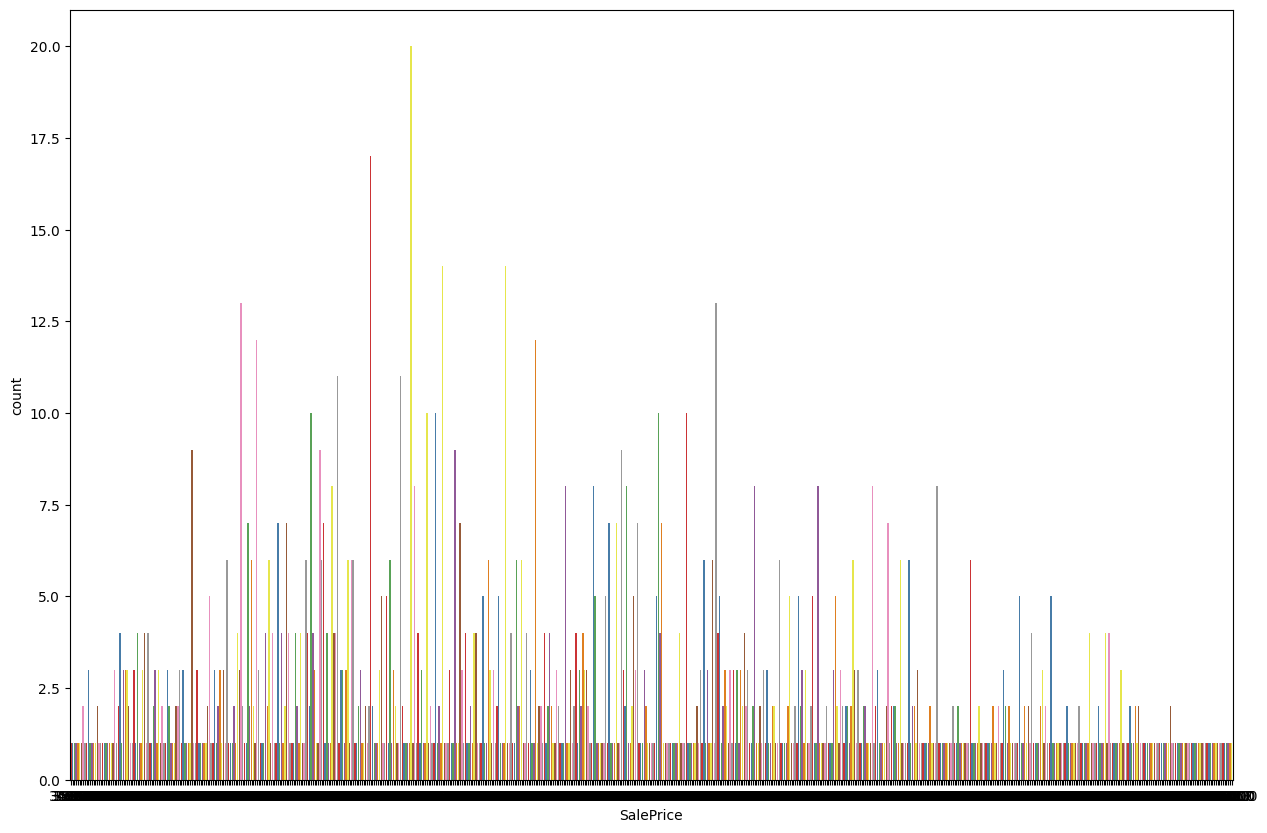

In [60]:
plt.figure(figsize = (15,10))
sns.countplot(x = df['SalePrice'] ,palette = "Set1")

/tmp/ipykernel_27194/19763324.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['LotArea'] , y = df['SalePrice'] , palette = 'Set1' )


<Axes: xlabel='LotArea', ylabel='SalePrice'>

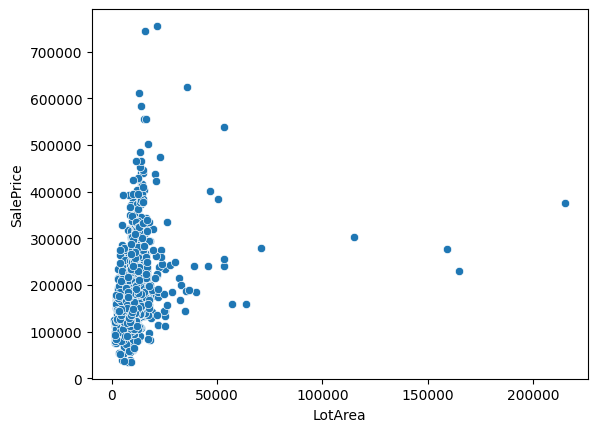

In [61]:
sns.scatterplot(x = df['LotArea'] , y = df['SalePrice'] , palette = 'Set1' )

/tmp/ipykernel_27194/3484711470.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['GrLivArea'] , y = df['SalePrice'] , palette = 'Set1' )


<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

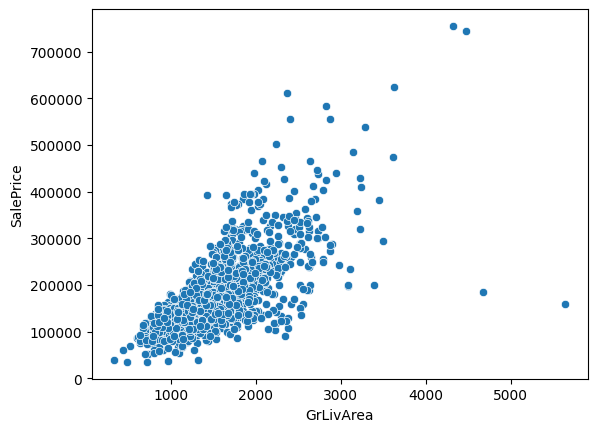

In [62]:
sns.scatterplot(x = df['GrLivArea'] , y = df['SalePrice'] , palette = 'Set1' )

/tmp/ipykernel_27194/4188159981.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x = df['TotalBsmtSF'] , y = df['SalePrice'] , palette = 'Set1' )


<Axes: xlabel='TotalBsmtSF', ylabel='SalePrice'>

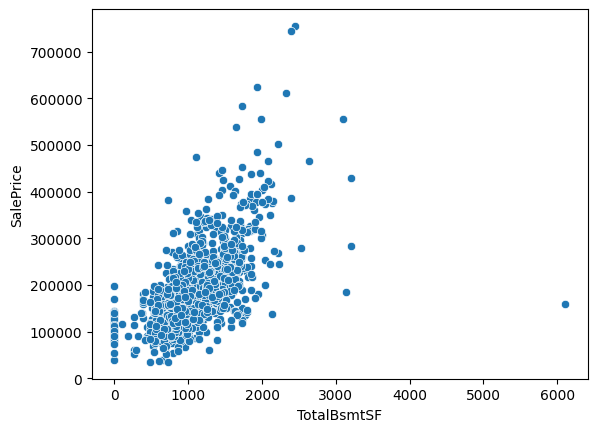

In [63]:
sns.scatterplot(x = df['TotalBsmtSF'] , y = df['SalePrice'] , palette = 'Set1' )

# CORRELATION ANALYSIS

In [65]:
corr = df.corr(numeric_only = True)
corr["SalePrice"].sort_values(ascending = False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
...,...
GarageType_Detchd,-0.354141
GarageFinish_Unf,-0.410608
BsmtQual_TA,-0.452394
KitchenQual_TA,-0.519298


# CATEGORICAL FEATURE ANALYSIS

In [66]:
df.select_dtypes(include = "object").columns

Index([], dtype='object')

# OUTLIER DETECTION

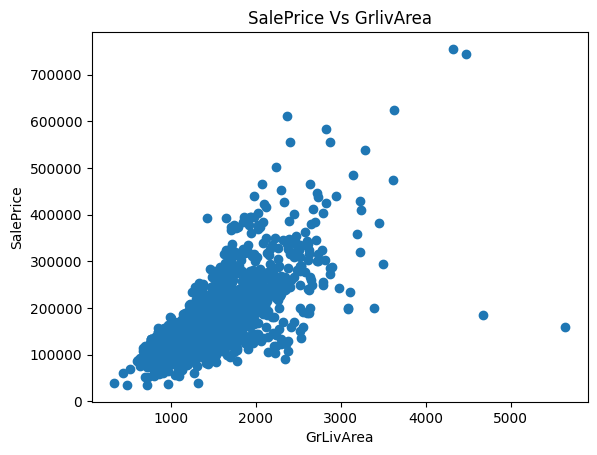

In [67]:
plt.scatter(x = df["GrLivArea"] , y = df['SalePrice'] )
plt.title("SalePrice Vs GrlivArea")
plt.xlabel("GrLivArea")
plt.ylabel('SalePrice')
plt.show()

# ONE HOT ENCODING

In [68]:
df = pd.get_dummies(
    data=df,
    columns=df.select_dtypes(include="object").columns,
     drop_first=True
)
df.sample(5)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1397,1398,70,51.0,6120,5,8,1920,2004,0.0,0,...,False,False,False,True,False,False,False,False,True,False
275,276,50,55.0,7264,7,7,1925,2007,0.0,0,...,False,False,False,True,False,False,False,False,True,False
1415,1416,120,51.0,3635,7,5,2007,2007,130.0,988,...,False,False,False,True,False,False,False,False,True,False
454,455,90,63.0,9297,5,5,1976,1976,0.0,1606,...,False,False,False,True,False,False,False,True,False,False
936,937,20,67.0,10083,7,5,2003,2003,0.0,833,...,False,False,False,True,False,False,False,False,True,False


# TRAIN TEST SPLIT

In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = "SalePrice")   # ---> feature
y = df["SalePrice"]                  # ---> target


In [70]:
# SPLIT
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print("X_train.shape  : ",X_train.shape)
print("X_test.shape   : ",X_test.shape)
print("y_train.shape  : ",y_train.shape)
print("y_test.shape   : ",y_test.shape)

X_train.shape  :  (1168, 288)
X_test.shape   :  (292, 288)
y_train.shape  :  (1168,)
y_test.shape   :  (292,)


# MODEL TRAINING

1. LINEAR REGRESSION

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
# Create model
model = LinearRegression()

In [73]:
# Train model
model.fit(X_train, y_train)

LinearRegression()

In [74]:
# Prediction
y_pred = model.predict(X_test)

In [75]:
# EVALUATION
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test , y_pred) )
print("RMSE:", rmse)

RMSE: 65370.216703979786


2. RIDGE REGRESSION

In [76]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

In [77]:
ridge = Ridge(alpha=1.0)

In [79]:
ridge.fit(X_train, y_train)

Ridge()

In [82]:
# PREDICTION
y_pred = ridge.predict(X_test)

In [83]:
# EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Ridge RMSE:", rmse)

Ridge RMSE: 29743.520367917263


3. LASSO REGRESSION

In [84]:
from sklearn.linear_model import Lasso

In [85]:
lasso = Lasso(alpha=0.001)

In [86]:
lasso.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.156e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=0.001)

In [87]:
# PREDICTION
y_pred = lasso.predict(X_test)

In [88]:
# EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Lasso RMSE:", rmse)

Lasso RMSE: 30461.051581997137


4. RANDOM FOREST REGRESSOR

In [89]:
from sklearn.ensemble import RandomForestRegressor

In [90]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [91]:
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [92]:
# PREDICTION
y_pred = rf.predict(X_test)

In [93]:
# EVALUATION
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Random Forest RMSE:", rmse)

Random Forest RMSE: 29215.600480542544
